PROJECT:    C:\Users\doria\Documents\EPFL\IA\iapr2026do\project
MODELS_DIR: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models
Loaded rank_clf from: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\rank_clf.pkl
Rank classes (16): [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('draw_2'), np.str_('draw_4'), np.str_('reverse'), np.str_('skip'), np.str_('token'), np.str_('wild')]


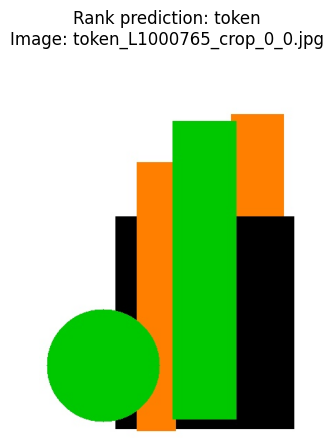

Predicted rank: token
Rank feature length used at inference: 1796


In [1]:

import os
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog as skimage_hog
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
cwd = Path.cwd().resolve()
if (cwd / "training_data").is_dir():
    PROJECT = cwd
elif (cwd.parent / "training_data").is_dir():
    PROJECT = cwd.parent.resolve()
else:
    raise FileNotFoundError(f"Could not locate project root from cwd: {cwd}")

MODELS_DIR       = PROJECT / "models"
AUG_DIR          = PROJECT / "training_data" / "training_images" / "augmented_cards"
RANK_CLF_PATH    = MODELS_DIR / "rank_clf.pkl"
RANK_CLASSES_PATH = MODELS_DIR / "rank_classes.npy"

print(f"PROJECT:    {PROJECT}")
print(f"MODELS_DIR: {MODELS_DIR}")

# Load model + classes
rank_clf    = joblib.load(RANK_CLF_PATH)
rank_classes = np.load(RANK_CLASSES_PATH, allow_pickle=True)
print(f"Loaded rank_clf from: {RANK_CLF_PATH}")
print(f"Rank classes ({len(rank_classes)}): {list(rank_classes)}")

IMG_SIZE = 128
FOURIER_COEFFS = 32

def letterbox_cv2(img_bgr, size=IMG_SIZE):
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), 128, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def extract_hog_feat(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )

def extract_fourier_feat(img_bgr, n_coeffs=FOURIER_COEFFS):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    bw[:8, :] = 0
    bw[-8:, :] = 0
    bw[:, :8] = 0
    bw[:, -8:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    pts = cnt[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    F = np.fft.fft(z)

    mag = np.abs(F)[1:n_coeffs + 1]
    if len(mag) < n_coeffs:
        mag = np.pad(mag, (0, n_coeffs - len(mag)))

    mag = mag / (mag[0] + 1e-6)
    return mag.astype(np.float32)

def extract_rank_feat(img_bgr):
    hog_vec = extract_hog_feat(img_bgr)
    fd_vec = extract_fourier_feat(img_bgr)
    return np.concatenate([hog_vec, fd_vec])

# Pick one image to test
aug_images = sorted([f for f in os.listdir(AUG_DIR) if f.lower().endswith(".jpg")])
if not aug_images:
    raise FileNotFoundError(f"No .jpg found in {AUG_DIR}")

img_name = aug_images[0]
img_path = os.path.join(AUG_DIR, img_name)
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read image: {img_path}")

img_lb = letterbox_cv2(img_bgr)
rank_vec = extract_rank_feat(img_lb)
pred_idx = int(rank_clf.predict(rank_vec.reshape(1, -1))[0])
pred_rank = rank_classes[pred_idx]

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Rank prediction: {pred_rank}\nImage: {img_name}")
plt.axis("off")
plt.show()

print(f"Predicted rank: {pred_rank}")
print(f"Rank feature length used at inference: {rank_vec.shape[0]}")


In [2]:
ref = Path.cwd().resolve()
print(ref.parent)
print(f"Current working directory: {ref}")

C:\Users\doria\Documents\EPFL\IA\iapr2026do\project
Current working directory: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\notebooks


Using segmenter: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\scene_segmenter_unet_small.pth
Testing on:      C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\iapr-26-uno-vision-challenge\train_images\L1000770.jpg
Boxes from segmenter mask: 4


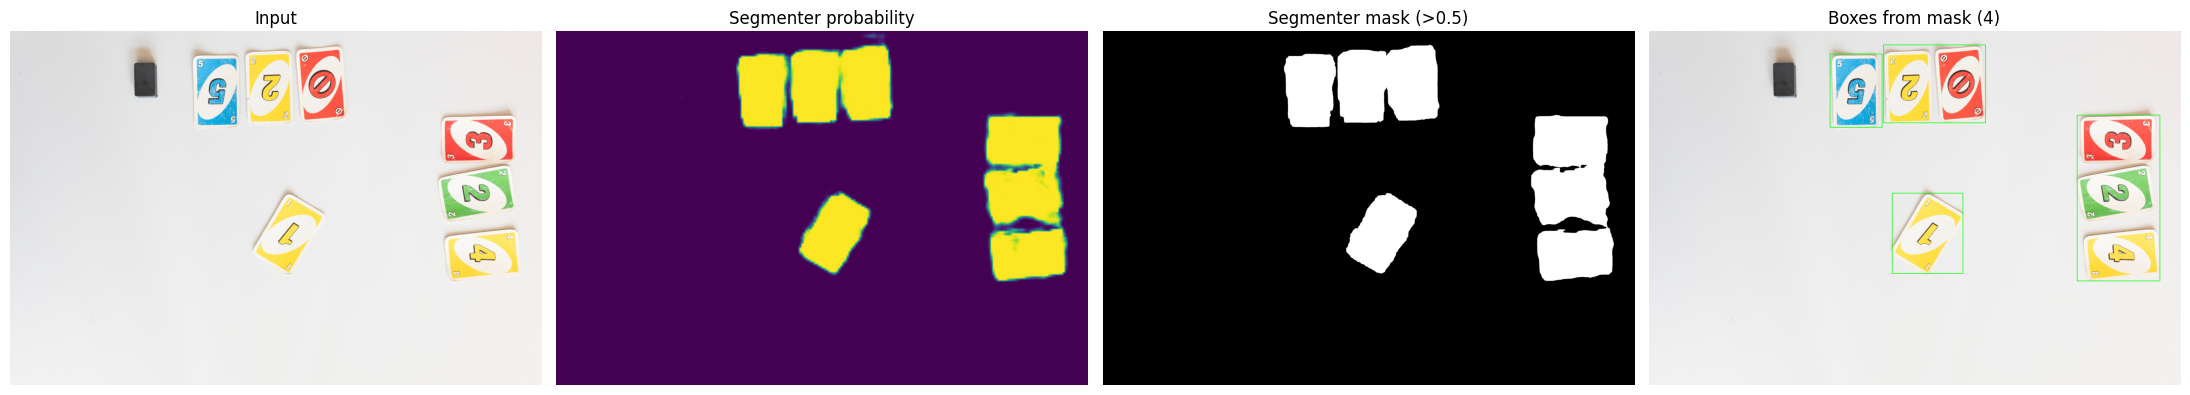

Loaded segmenter model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\scene_segmenter_unet_small.pth
Input image: C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\iapr-26-uno-vision-challenge\train_images\L1000770.jpg
Foreground pixels (mask>0.5): 1386611


In [3]:

import os
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_IMAGES_DIR = PROJECT.parent / "data" / "iapr-26-uno-vision-challenge" / "train_images"
SEG_MODEL_PATH   = PROJECT / "models" / "scene_segmenter_unet_small.pth"

if not SEG_MODEL_PATH.is_file():
    raise FileNotFoundError(f"Segmenter model not found: {SEG_MODEL_PATH}")

# Pick the first available train image for testing
train_images = sorted(TRAIN_IMAGES_DIR.glob("*.jpg"))
if not train_images:
    raise FileNotFoundError(f"No .jpg images found in {TRAIN_IMAGES_DIR}")
TEST_IMG_PATH = train_images[0]
print(f"Using segmenter: {SEG_MODEL_PATH}")
print(f"Testing on:      {TEST_IMG_PATH}")

# Same architecture used in training
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


IMG_SIZE = 256


def letterbox_with_meta(img_pil, target_size=IMG_SIZE, fill=255, interpolation=Image.BILINEAR):
    w, h = img_pil.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img_resized = img_pil.resize((new_w, new_h), interpolation)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    left = pad_w // 2
    top = pad_h // 2
    right = pad_w - left
    bottom = pad_h - top

    img_lb = TF.pad(img_resized, (left, top, right, bottom), fill=fill)
    meta = {
        "orig_w": w,
        "orig_h": h,
        "new_w": new_w,
        "new_h": new_h,
        "left": left,
        "top": top,
        "target": target_size,
    }
    return img_lb, meta


def unletterbox_mask(mask_lb, meta):
    left, top = meta["left"], meta["top"]
    new_w, new_h = meta["new_w"], meta["new_h"]
    orig_w, orig_h = meta["orig_w"], meta["orig_h"]

    core = mask_lb[top:top + new_h, left:left + new_w]
    core = cv2.resize(core, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    return core


def boxes_from_mask(mask_bin, img_area, max_components=24):
    """Extract bounding boxes from a binary segmentation mask via connected components."""
    # Light morphology to close small holes and remove noise
    kernel = np.ones((5, 5), np.uint8)
    clean = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel)

    n_labels, _, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
    if n_labels <= 1:
        return []

    min_area = max(500, int(0.0005 * img_area))
    areas = stats[1:, cv2.CC_STAT_AREA]
    selected_idx = np.argsort(areas)[::-1][: min(max_components, len(areas))] + 1

    boxes = []
    for label_idx in selected_idx:
        x = int(stats[label_idx, cv2.CC_STAT_LEFT])
        y = int(stats[label_idx, cv2.CC_STAT_TOP])
        bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        area = bw * bh
        ar = bw / max(1, bh)
        if area >= min_area and 0.15 <= ar <= 4.0:
            boxes.append((x, y, bw, bh))

    return boxes


# ── Load image ────────────────────────────────────────────────────────────────
img_bgr = cv2.imread(str(TEST_IMG_PATH))
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read test image: {TEST_IMG_PATH}")

H, W = img_bgr.shape[:2]

# ── Load segmenter ────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetSmall().to(device)
model.load_state_dict(torch.load(str(SEG_MODEL_PATH), map_location=device))
model.eval()

# ── Run segmenter on the full image (single forward pass) ─────────────────────
img_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
img_lb, meta = letterbox_with_meta(img_pil, IMG_SIZE, fill=255, interpolation=Image.BILINEAR)

x_t = TF.to_tensor(img_lb)
x_t = TF.normalize(x_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x_t)
    prob_lb = torch.sigmoid(logits)[0, 0].cpu().numpy()

global_prob = unletterbox_mask(prob_lb, meta)
mask_bin = (global_prob > 0.5).astype(np.uint8)

# ── Extract bounding boxes from segmenter mask ────────────────────────────────
boxes = boxes_from_mask(mask_bin, H * W, max_components=24)
print(f"Boxes from segmenter mask: {len(boxes)}")

# ── Visualize ─────────────────────────────────────────────────────────────────
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_boxes = img_rgb.copy()
for (x, y, bw, bh) in boxes:
    cv2.rectangle(img_boxes, (x, y), (x + bw, y + bh), (0, 255, 0), 3)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(global_prob, cmap="viridis")
axes[1].set_title("Segmenter probability")
axes[1].axis("off")

axes[2].imshow(mask_bin, cmap="gray")
axes[2].set_title("Segmenter mask (>0.5)")
axes[2].axis("off")

axes[3].imshow(img_boxes)
axes[3].set_title(f"Boxes from mask ({len(boxes)})")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print(f"Loaded segmenter model: {SEG_MODEL_PATH}")
print(f"Input image: {TEST_IMG_PATH}")
print(f"Foreground pixels (mask>0.5): {int(mask_bin.sum())}")


Foreground pixels at threshold 0.97: 1191760
Watershed regions: 8
Valid boxes: 8


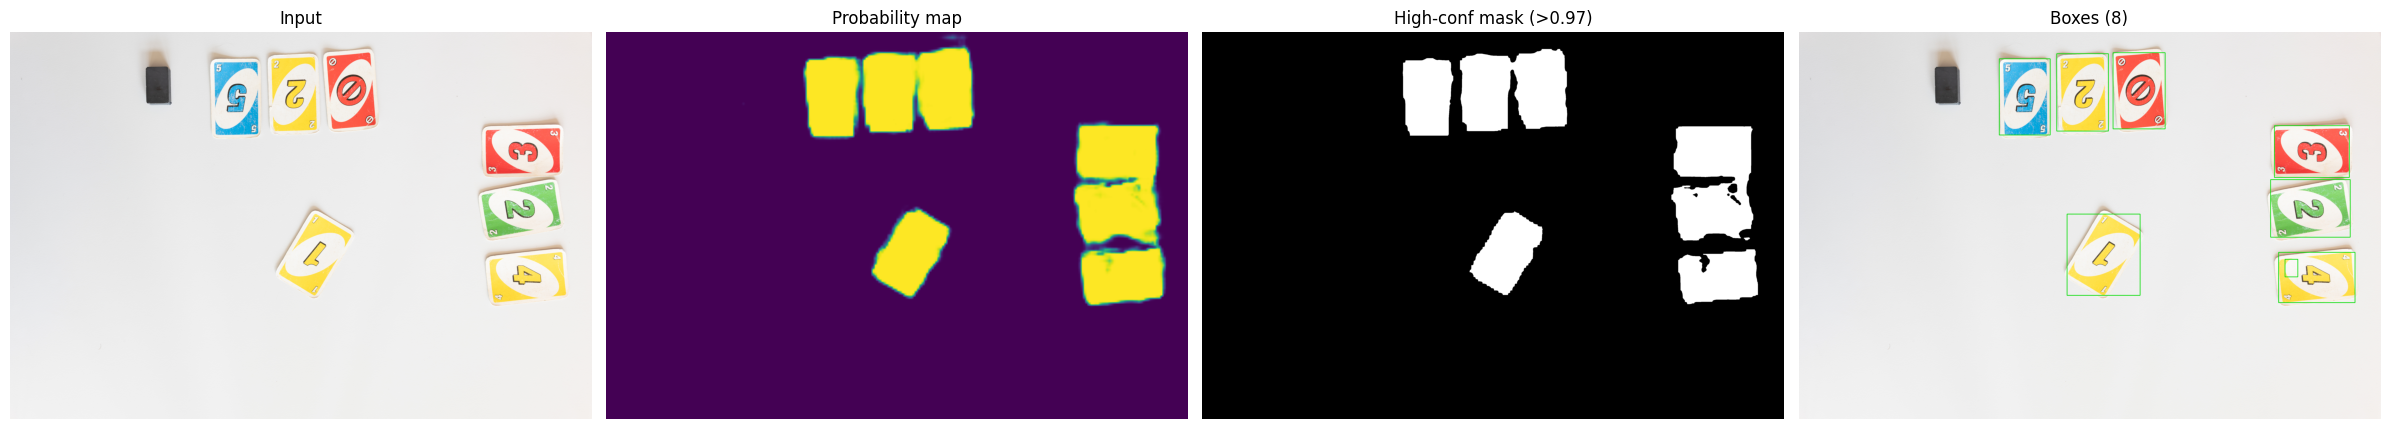

In [4]:

# ── Post-processing: high-confidence mask → watershed ─────────────────────────

import numpy as np
import cv2
import matplotlib.pyplot as plt

# ── Tunable ───────────────────────────────────────────────────────────────────
HIGH_THRESH  = 0.97   # keep only high-confidence (yellow on viridis) foreground
FG_THRESHOLD = 0.45   # distance-map fraction for sure-foreground seeds
MIN_BOX_AREA = max(500, int(0.0005 * H * W))
AR_MIN, AR_MAX = 0.15, 4.0

kernel5 = np.ones((5, 5), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)

# ── High-confidence mask ──────────────────────────────────────────────────────
mask_high = (global_prob > HIGH_THRESH).astype(np.uint8)
# Close small holes, remove tiny specks
mask_high = cv2.morphologyEx(mask_high, cv2.MORPH_CLOSE, kernel5)
mask_high = cv2.morphologyEx(mask_high, cv2.MORPH_OPEN,  kernel5)

print(f"Foreground pixels at threshold {HIGH_THRESH}: {int(mask_high.sum())}")

# ── Watershed ─────────────────────────────────────────────────────────────────
sure_bg = cv2.dilate(mask_high, kernel7, iterations=5)
dist    = cv2.distanceTransform(mask_high, cv2.DIST_L2, 5)
norm    = cv2.normalize(dist, None, 0.0, 1.0, cv2.NORM_MINMAX)
_, sure_fg = cv2.threshold(norm, FG_THRESHOLD, 1.0, cv2.THRESH_BINARY)
sure_fg    = sure_fg.astype(np.uint8)
unknown    = cv2.subtract(sure_bg, sure_fg)
n, mkrs    = cv2.connectedComponents(sure_fg)
mkrs       = mkrs + 1
mkrs[unknown == 1] = 0
cv2.watershed(img_bgr.copy(), mkrs)

print(f"Watershed regions: {n - 1}")

# ── Bounding boxes ────────────────────────────────────────────────────────────
boxes = []
for lid in range(2, n + 1):
    comp = (mkrs == lid).astype(np.uint8)
    if comp.sum() == 0:
        continue
    x, y, bw, bh = cv2.boundingRect(comp)
    ar = bw / max(1, bh)
    if bw * bh >= MIN_BOX_AREA and AR_MIN <= ar <= AR_MAX:
        boxes.append((x, y, bw, bh))

print(f"Valid boxes: {len(boxes)}")

# ── Visualise ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(0)

def colorise_markers(mkrs, n):
    cmap = np.zeros((*mkrs.shape, 3), dtype=np.uint8)
    for lid in range(2, n + 1):
        cmap[mkrs == lid] = rng.integers(60, 255, 3)
    cmap[mkrs == -1] = [255, 0, 0]
    return cmap

img_boxes = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
for (x, y, bw, bh) in boxes:
    cv2.rectangle(img_boxes, (x, y), (x + bw, y + bh), (0, 220, 0), 3)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(global_prob, cmap="viridis")
axes[1].set_title(f"Probability map")
axes[1].axis("off")

axes[2].imshow(mask_high, cmap="gray")
axes[2].set_title(f"High-conf mask (>{HIGH_THRESH})")
axes[2].axis("off")

axes[3].imshow(img_boxes)
axes[3].set_title(f"Boxes ({len(boxes)})")
axes[3].axis("off")

plt.tight_layout()
plt.show()


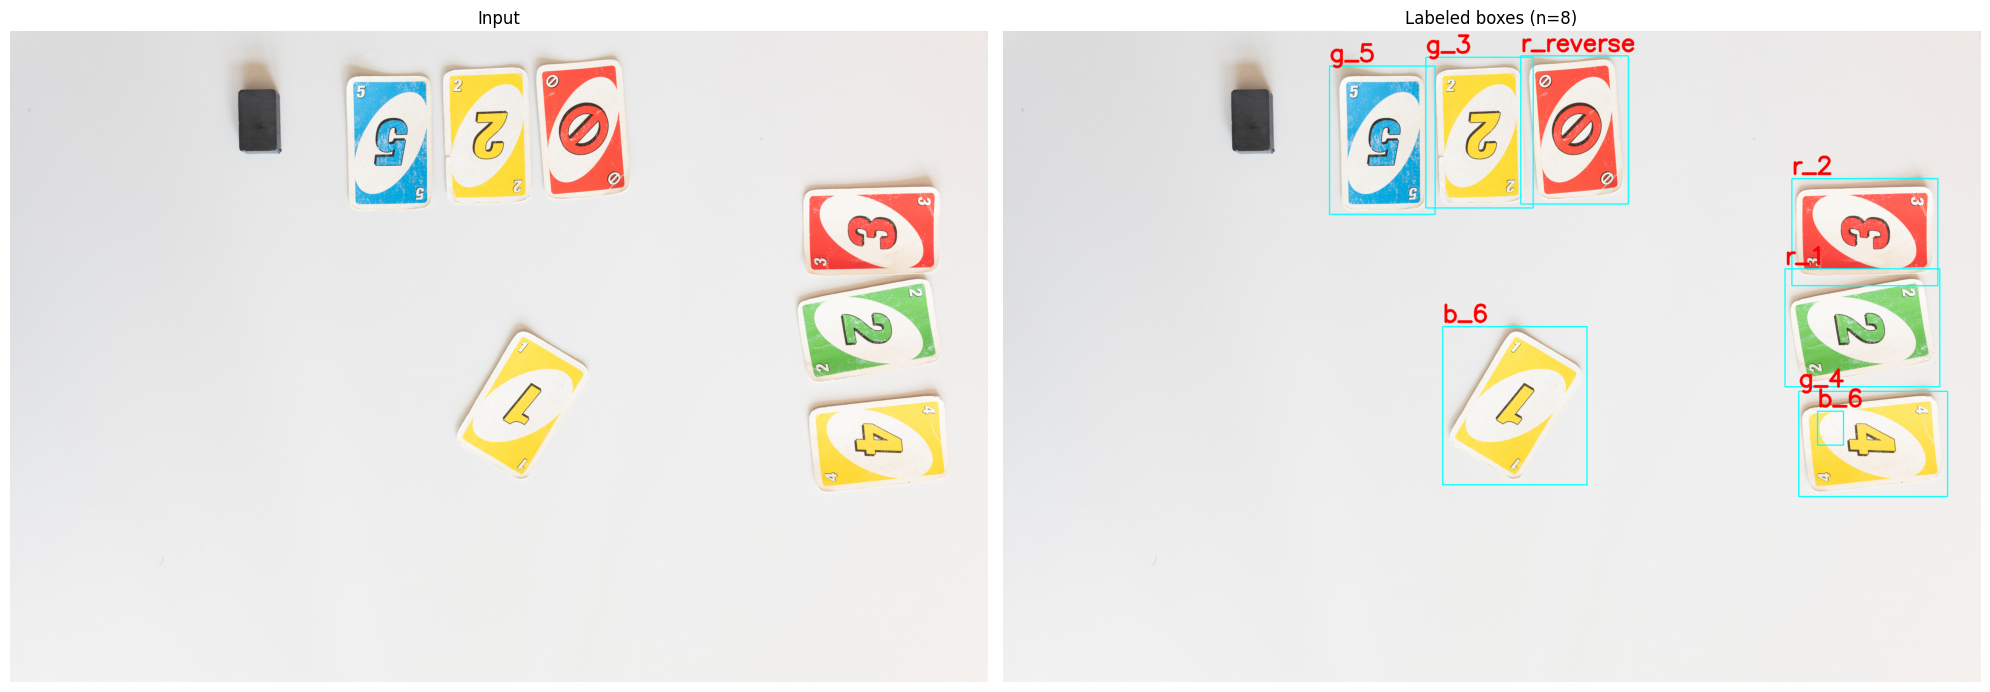

Predictions per box:
  Box 00: (2117,101)-(2557,707) -> r_reverse
  Box 01: (1729,107)-(2168,723) -> g_3
  Box 02: (1335,143)-(1767,749) -> g_5
  Box 03: (3226,603)-(3823,1041) -> r_2
  Box 04: (3198,972)-(3831,1454) -> r_1
  Box 05: (1798,1208)-(2388,1855) -> b_6
  Box 06: (3254,1473)-(3863,1903) -> g_4
  Box 07: (3331,1554)-(3437,1693) -> b_6


In [5]:

import os
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog as skimage_hog

# Uses variables produced by cell 3: img_bgr, boxes
if "img_bgr" not in globals() or "boxes" not in globals():
    raise RuntimeError("Run cell 3 first so 'img_bgr' and 'boxes' are available.")

COLOR_CLF_PATH    = MODELS_DIR / "color_clf.pkl"
RANK_CLF_PATH     = MODELS_DIR / "rank_clf.pkl"
COLOR_CLASSES_PATH = MODELS_DIR / "color_classes.npy"
RANK_CLASSES_PATH  = MODELS_DIR / "rank_classes.npy"

color_clf    = joblib.load(COLOR_CLF_PATH)
rank_clf     = joblib.load(RANK_CLF_PATH)
color_classes = np.load(COLOR_CLASSES_PATH, allow_pickle=True)
rank_classes  = np.load(RANK_CLASSES_PATH, allow_pickle=True)

IMG_SIZE = 128
LABEL_SCALE = 3.25
LABEL_THICKNESS = 10
FOURIER_COEFFS = 32

# Pseudo-color labels that mean "no real color"
NO_COLOR_LABELS = {"__special__", "__token__"}

def letterbox_cv2(img_bgr, size=IMG_SIZE):
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), 128, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def extract_color_feat(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = (hsv[:, :, 1] > 40).astype(np.uint8) * 255
    h_hist = cv2.calcHist([hsv], [0], mask, [32], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], mask, [16], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist])
    return feat / (feat.sum() + 1e-6)

def extract_hog_feat(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )

def extract_fourier_feat(img_bgr, n_coeffs=FOURIER_COEFFS):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    bw[:8, :] = 0;  bw[-8:, :] = 0
    bw[:, :8] = 0;  bw[:, -8:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    pts = cnt[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    F = np.fft.fft(z)
    mag = np.abs(F)[1:n_coeffs + 1]
    if len(mag) < n_coeffs:
        mag = np.pad(mag, (0, n_coeffs - len(mag)))
    mag = mag / (mag[0] + 1e-6)
    return mag.astype(np.float32)

def extract_rank_feat(img_bgr):
    return np.concatenate([extract_hog_feat(img_bgr), extract_fourier_feat(img_bgr)])

# Classify each box detected in cell 3
vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
pred_rows = []

for i, (x, y, bw, bh) in enumerate(boxes):
    margin = int(0.08 * max(bw, bh))
    x0 = max(0, x - margin)
    y0 = max(0, y - margin)
    x1 = min(img_bgr.shape[1], x + bw + margin)
    y1 = min(img_bgr.shape[0], y + bh + margin)

    crop    = img_bgr[y0:y1, x0:x1]
    crop_lb = letterbox_cv2(crop)

    color_idx = int(color_clf.predict(extract_color_feat(crop_lb).reshape(1, -1))[0])
    rank_idx  = int(rank_clf.predict(extract_rank_feat(crop_lb).reshape(1, -1))[0])

    color_name = str(color_classes[color_idx])
    rank_name  = str(rank_classes[rank_idx])

    # Colorless cards: rank is the full label
    if color_name in NO_COLOR_LABELS:
        label = rank_name
    else:
        label = f"{color_name}_{rank_name}"

    pred_rows.append((i, x0, y0, x1, y1, label))

    cv2.rectangle(vis, (x0, y0), (x1, y1), (0, 255, 255), 3)
    y_text = y0 - 20 if y0 - 20 > 20 else y0 + 50
    cv2.putText(vis, label, (x0, y_text),
                cv2.FONT_HERSHEY_SIMPLEX, LABEL_SCALE, (255, 0, 0), LABEL_THICKNESS, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(vis)
axes[1].set_title(f"Labeled boxes (n={len(pred_rows)})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Predictions per box:")
for i, x0, y0, x1, y1, label in pred_rows:
    print(f"  Box {i:02d}: ({x0},{y0})-({x1},{y1}) -> {label}")


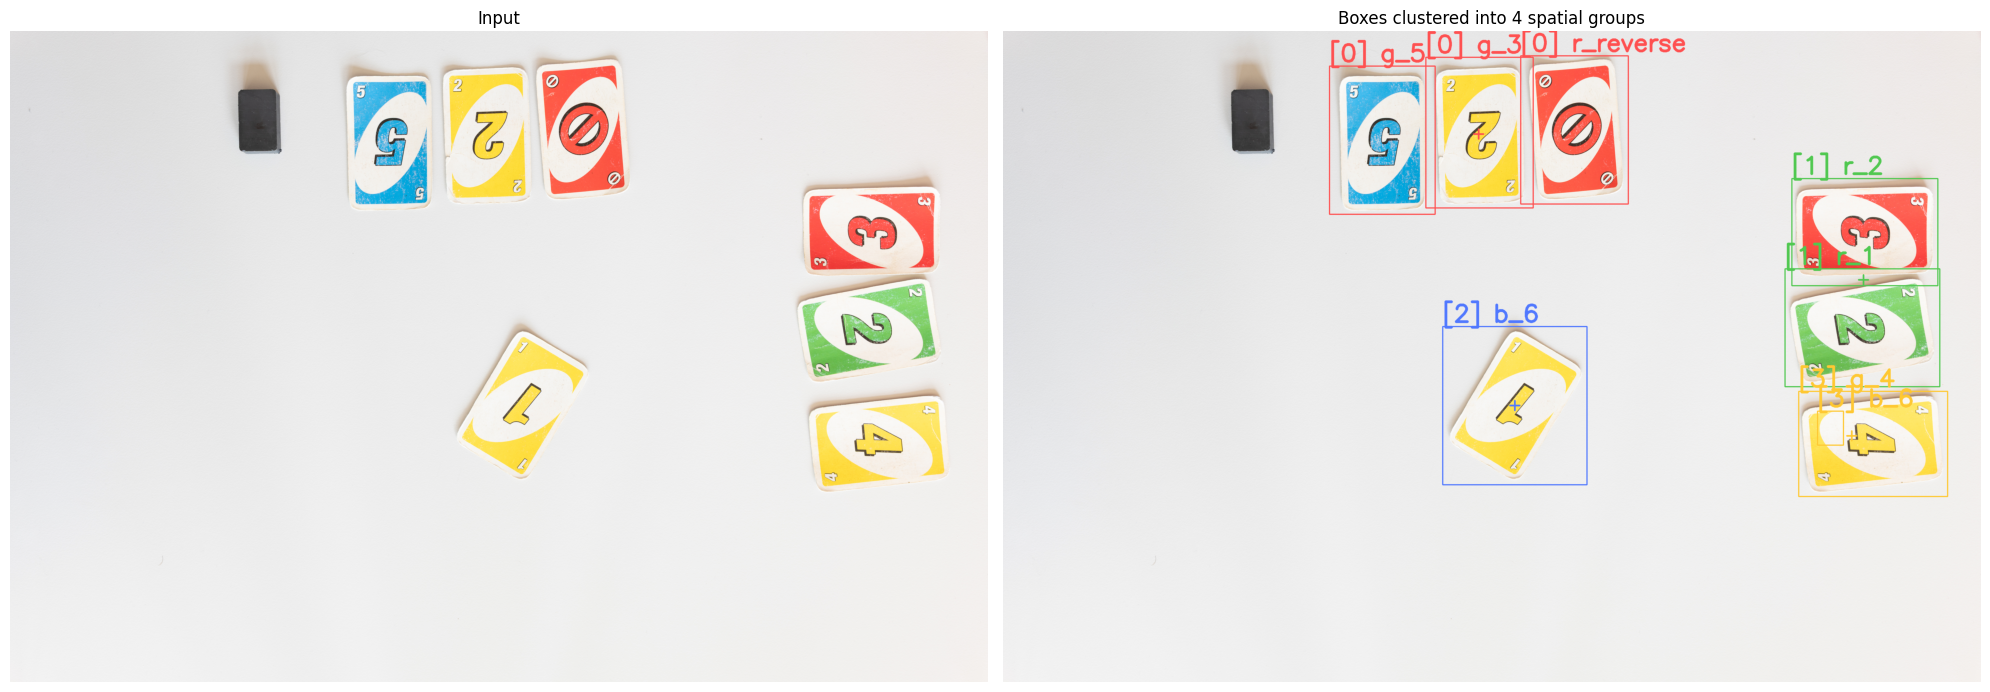


Cluster assignments (4 clusters):
  Cluster 0  centre=(1946,422)  cards=['r_reverse', 'g_3', 'g_5']
  Cluster 1  centre=(3520,1018)  cards=['r_2', 'r_1']
  Cluster 2  centre=(2093,1532)  cards=['b_6']
  Cluster 3  centre=(3471,1656)  cards=['g_4', 'b_6']


In [6]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Use box centres as position features
centres = np.array([[(x0 + x1) / 2, (y0 + y1) / 2] for _, x0, y0, x1, y1, _ in pred_rows])
labels_box = [label for _, _, _, _, _, label in pred_rows]

# Choose either:
# 1) fixed number of clusters
N_CLUSTERS = 4
clusterer = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="average")

# OR 2) cluster by a distance threshold instead of forcing N clusters
# DIST_THRESHOLD = 250
# clusterer = AgglomerativeClustering(
#     n_clusters=None,
#     distance_threshold=DIST_THRESHOLD,
#     linkage="average"
# )

cluster_ids = clusterer.fit_predict(centres)
unique_clusters = sorted(np.unique(cluster_ids))
n_clusters_found = len(unique_clusters)

CLUSTER_COLORS = [
    (255,  80,  80),
    ( 80, 200,  80),
    ( 80, 120, 255),
    (255, 200,  50),
    (220,  80, 220),
]

vis_cl = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)

for (_, x0, y0, x1, y1, label), cid in zip(pred_rows, cluster_ids):
    color = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    cv2.rectangle(vis_cl, (x0, y0), (x1, y1), color, 3)
    y_text = y0 - 20 if y0 - 20 > 20 else y0 + 50
    cv2.putText(
        vis_cl, f"[{cid}] {label}", (x0, y_text),
        cv2.FONT_HERSHEY_SIMPLEX, LABEL_SCALE, color, LABEL_THICKNESS, cv2.LINE_AA
    )

# Compute visual cluster centres manually
cluster_centres = []
for cid in unique_clusters:
    pts = centres[cluster_ids == cid]
    cx, cy = pts.mean(axis=0)
    cluster_centres.append((cid, cx, cy))
    cv2.drawMarker(
        vis_cl, (int(cx), int(cy)), CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
        markerType=cv2.MARKER_CROSS, markerSize=40, thickness=5
    )

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(vis_cl)
axes[1].set_title(f"Boxes clustered into {n_clusters_found} spatial groups")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"\nCluster assignments ({n_clusters_found} clusters):")
for cid, cx, cy in cluster_centres:
    members = [labels_box[i] for i, c in enumerate(cluster_ids) if c == cid]
    print(f"  Cluster {cid}  centre=({cx:.0f},{cy:.0f})  cards={members}")